# SVM: Predict Good vs Poor QoE
Business Problem

Classify mobile user experience.

Target:

0 = Poor QoE
1 = Good QoE

## Step 1 – Generate Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

latency = np.random.uniform(10, 300, n)
packet_loss = np.random.uniform(0, 10, n)

qoe = (
    (latency < 120)
    &
    (packet_loss < 3)
)

qoe = qoe.astype(int)

df = pd.DataFrame({
    'latency': latency,
    'packet_loss': packet_loss,
    'qoe': qoe
})

df.head()

,latency,packet_loss,qoe
0,118.616634,6.420316,0
1,285.707149,0.841400,0
2,222.278243,1.616287,0
3,183.610960,8.985542,0
4,55.245406,6.064291,0


## Step 2 – Visualize Data

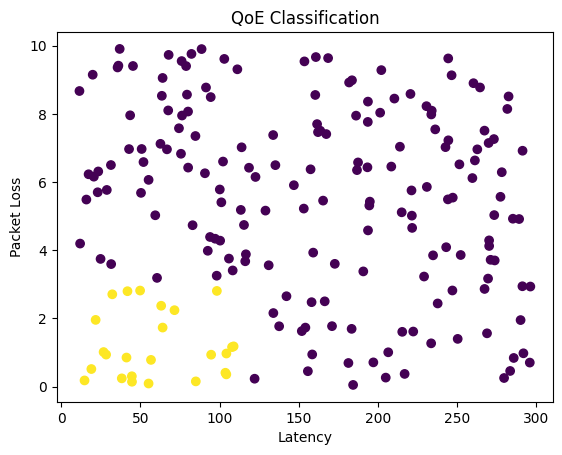

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df['latency'],
    df['packet_loss'],
    c=df['qoe']
)

plt.xlabel("Latency")
plt.ylabel("Packet Loss")
plt.title("QoE Classification")

plt.show()

## Step 3 – Build Model

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X = df[['latency', 'packet_loss']]
y = df['qoe']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = SVC(
    kernel='rbf'
)

model.fit(X_train, y_train)

SVC()

## Step 4 – Predict

In [4]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


## Step 5 – Evaluate

In [5]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.94


## Step 6 – Plot Predictions

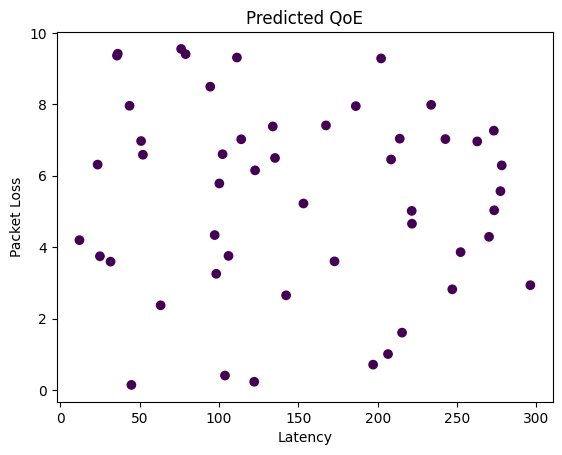

In [6]:
plt.scatter(
    X_test['latency'],
    X_test['packet_loss'],
    c=predictions
)

plt.xlabel("Latency")
plt.ylabel("Packet Loss")
plt.title("Predicted QoE")

plt.show()

## Summary
Input:
- Latency
- Packet Loss

Output:
- Good QoE
- Poor QoE

Goal:
Find a boundary between classes

## SVM – QoE Classification

SVM visualization is very similar but also shows the margin.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


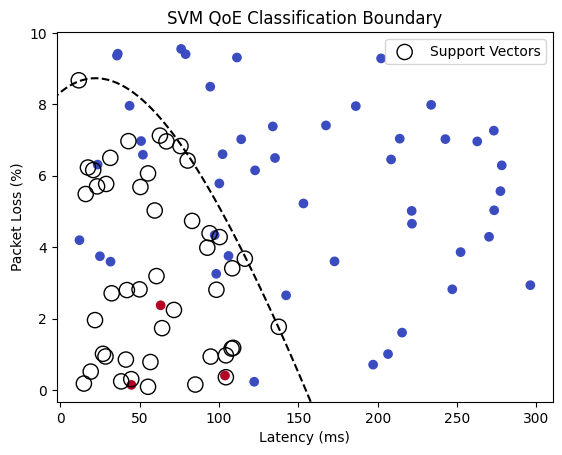

In [7]:
# ==========================================
# SVM Decision Boundary
# ==========================================

plt.scatter(
    X_test['latency'],
    X_test['packet_loss'],
    c=y_test,
    cmap="coolwarm"
)


ax = plt.gca()

xlim=ax.get_xlim()
ylim=ax.get_ylim()


xx,yy=np.meshgrid(
    np.linspace(
        xlim[0],
        xlim[1],
        100
    ),
    np.linspace(
        ylim[0],
        ylim[1],
        100
    )
)


grid=np.c_[
    xx.ravel(),
    yy.ravel()
]


Z=model.decision_function(grid)

Z=Z.reshape(xx.shape)


# Decision boundary + margins

plt.contour(
    xx,
    yy,
    Z,
    colors='black',
    levels=[-1,0,1],
    linestyles=[
        '--',
        '-',
        '--'
    ]
)


# Support vectors

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)


plt.xlabel(
    "Latency (ms)"
)

plt.ylabel(
    "Packet Loss (%)"
)


plt.title(
    "SVM QoE Classification Boundary"
)

plt.legend()

plt.show()

          Poor QoE

        ○ ○ ○
          |
----------|----------  decision boundary
          |
        ● ● ●

          Good QoE

The black circles are:

Support Vectors

They define the SVM boundary.
